In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score,r2_score
from sklearn.model_selection import train_test_split

In [65]:
np.random.seed(2)
x = np.random.rand(100, 1) - 0.5
y = 3*x**2+ 0.07 * np.random.randn(100,1)
np.set_printoptions(suppress=True,precision=2)
x.shape,y.shape,x,y

((100, 1),
 (100, 1),
 array([[-0.06],
        [-0.47],
        [ 0.05],
        [-0.06],
        [-0.08],
        [-0.17],
        [-0.3 ],
        [ 0.12],
        [-0.2 ],
        [-0.23],
        [ 0.12],
        [ 0.03],
        [-0.37],
        [ 0.01],
        [-0.32],
        [ 0.29],
        [ 0.35],
        [-0.01],
        [ 0.35],
        [-0.42],
        [ 0.01],
        [-0.43],
        [-0.07],
        [-0.4 ],
        [-0.37],
        [ 0.1 ],
        [-0.27],
        [-0.39],
        [-0.28],
        [-0.15],
        [-0.03],
        [-0.3 ],
        [ 0.14],
        [-0.02],
        [ 0.01],
        [-0.11],
        [ 0.29],
        [ 0.08],
        [-0.34],
        [ 0.2 ],
        [ 0.46],
        [ 0.  ],
        [ 0.39],
        [-0.16],
        [ 0.07],
        [-0.07],
        [-0.06],
        [ 0.28],
        [ 0.04],
        [ 0.45],
        [ 0.04],
        [-0.42],
        [-0.13],
        [ 0.35],
        [-0.09],
        [-0.47],
        [-0.25],
        [

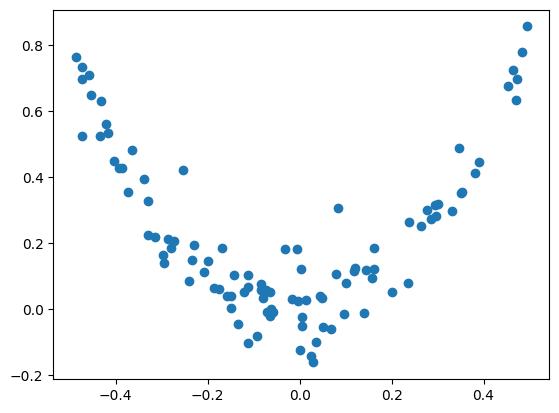

In [28]:
plt.scatter(x,y)
plt.show()

In [29]:
data=pd.DataFrame()
data['x']=x.reshape(-1,)
data['y']=y.reshape(-1,)
data

,x,y
0,-0.064005,-0.020050
1,-0.474074,0.698800
2,0.049662,0.034130
3,-0.064678,0.052189
4,-0.079632,0.033318
...,...,...
95,-0.083247,0.056796
96,0.143842,0.120134
97,0.161481,0.122372
98,-0.329523,0.224020


In [30]:
data['pred1']=data['y'].mean()
m1=data['y'].mean()
data

,x,y,pred1
0,-0.064005,-0.020050,0.224144
1,-0.474074,0.698800,0.224144
2,0.049662,0.034130,0.224144
3,-0.064678,0.052189,0.224144
4,-0.079632,0.033318,0.224144
...,...,...,...
95,-0.083247,0.056796,0.224144
96,0.143842,0.120134,0.224144
97,0.161481,0.122372,0.224144
98,-0.329523,0.224020,0.224144


In [31]:
data['res1']=data['y']-data['pred1']
data

,x,y,pred1,res1
0,-0.064005,-0.020050,0.224144,-0.244194
1,-0.474074,0.698800,0.224144,0.474656
2,0.049662,0.034130,0.224144,-0.190014
3,-0.064678,0.052189,0.224144,-0.171955
4,-0.079632,0.033318,0.224144,-0.190825
...,...,...,...,...
95,-0.083247,0.056796,0.224144,-0.167348
96,0.143842,0.120134,0.224144,-0.104010
97,0.161481,0.122372,0.224144,-0.101772
98,-0.329523,0.224020,0.224144,-0.000123


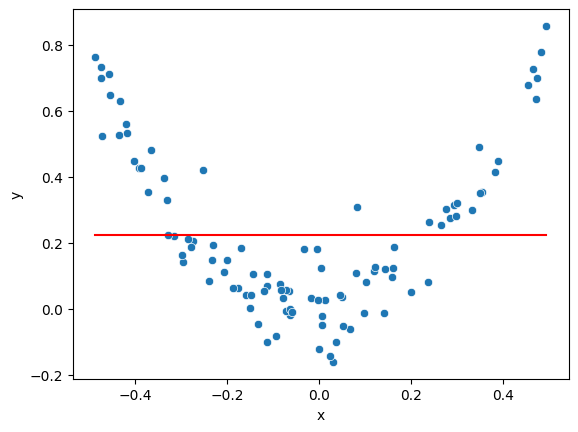

In [32]:
sns.scatterplot(x=data['x'],y=data['y'])
sns.lineplot(x=data['x'],y=data['pred1'],color='r')
plt.show()

In [33]:
m2=DecisionTreeRegressor(max_leaf_nodes=8)
m2.fit(data['x'].values.reshape(-1,1),data['res1'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

In [34]:
x_test=np.linspace(-0.5,0.5,100)
y_test=m1+m2.predict(x_test.reshape(-1,1))

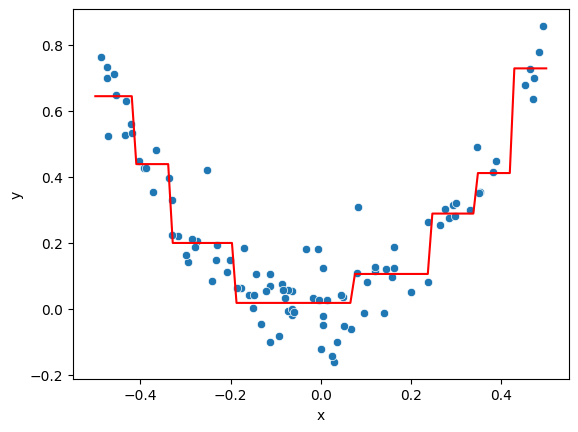

In [35]:
sns.scatterplot(x=data['x'],y=data['y'])
sns.lineplot(x=x_test,y=y_test.reshape(-1,),color='r')
plt.show()

In [36]:
data['pred2']=data['pred1']+m2.predict(data['x'].values.reshape(-1,1))
data

,x,y,pred1,res1,pred2
0,-0.064005,-0.020050,0.224144,-0.244194,0.017406
1,-0.474074,0.698800,0.224144,0.474656,0.644121
2,0.049662,0.034130,0.224144,-0.190014,0.017406
3,-0.064678,0.052189,0.224144,-0.171955,0.017406
4,-0.079632,0.033318,0.224144,-0.190825,0.017406
...,...,...,...,...,...
95,-0.083247,0.056796,0.224144,-0.167348,0.017406
96,0.143842,0.120134,0.224144,-0.104010,0.105201
97,0.161481,0.122372,0.224144,-0.101772,0.105201
98,-0.329523,0.224020,0.224144,-0.000123,0.199169


In [37]:
data['res2']=data['y']-data['pred2']
data

,x,y,pred1,res1,pred2,res2
0,-0.064005,-0.020050,0.224144,-0.244194,0.017406,-0.037457
1,-0.474074,0.698800,0.224144,0.474656,0.644121,0.054679
2,0.049662,0.034130,0.224144,-0.190014,0.017406,0.016723
3,-0.064678,0.052189,0.224144,-0.171955,0.017406,0.034783
4,-0.079632,0.033318,0.224144,-0.190825,0.017406,0.015912
...,...,...,...,...,...,...
95,-0.083247,0.056796,0.224144,-0.167348,0.017406,0.039390
96,0.143842,0.120134,0.224144,-0.104010,0.105201,0.014933
97,0.161481,0.122372,0.224144,-0.101772,0.105201,0.017171
98,-0.329523,0.224020,0.224144,-0.000123,0.199169,0.024851


In [38]:
m3=DecisionTreeRegressor(max_leaf_nodes=8)
m3.fit(data['x'].values.reshape(-1,1),data['res2'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

In [39]:
x_test=np.linspace(-0.5,0.5,100)
y_test=m1+m2.predict(x_test.reshape(-1,1))+m3.predict(x_test.reshape(-1,1))

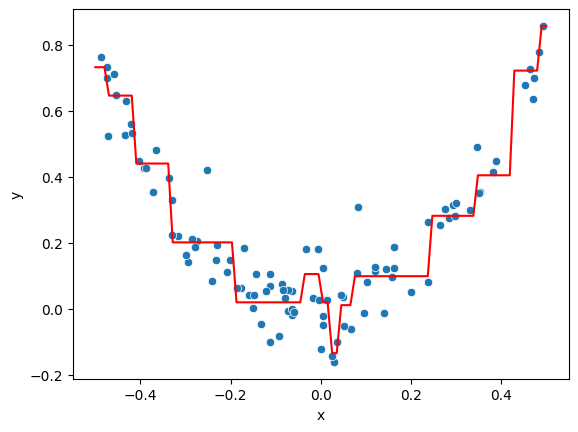

In [40]:
sns.scatterplot(x=data['x'],y=data['y'])
sns.lineplot(x=x_test,y=y_test,color='r')
plt.show()

In [47]:
def gradient_boost(X,y,number,lr,count=1,regs=[],foo=None):

  if number == 0:
    return 
  else:
    # do gradient boosting

    if count > 1:
      y = y - regs[-1].predict(X)
    else:
      foo = y

    tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree_reg.fit(X, y)

    regs.append(tree_reg)

    x1 = np.linspace(-0.5, 0.5, 500)
    y_pred = sum(lr * regressor.predict(x1.reshape(-1, 1)) for regressor in regs)

    print(number)
    plt.figure()
    plt.plot(x1, y_pred, linewidth=2)
    plt.plot(X[:, 0], foo,"r.")
    plt.show()

    gradient_boost(X,y,number-1,lr,count+1,regs,foo=foo)

Dont know whether above code runs of not its just for reference of concent that how this algorithm works.

Below class is made by me and it is somehow running

In [187]:
class gradient_boosting:
    def __init__(self,lr=0.01,n_estimators=500):
        self.lr=lr
        self.n_estimators=n_estimators
        self.models=[]
    def fit(self,x,y):
        self.base_model=float(y.mean())
        err=y-np.array([self.base_model for i in range(y.shape[0])]).reshape(-1,1)
        for i in range(self.n_estimators):
            m=DecisionTreeRegressor(max_depth=5,random_state=2)
            m.fit(x,err)
            self.models.append(m)
            err=err-self.lr*self.models[-1].predict(x).reshape(-1,1)
    def predict(self,x):
        ans=np.array([self.base_model for i in range(x.shape[0])]).reshape(-1,1)
        for i in self.models:
            ans=ans+self.lr*i.predict(x).reshape(-1,1)
        return ans

In [188]:
np.random.seed(2)
x = np.random.rand(100, 1) - 0.5
y = 3*x**2+ 0.07 * np.random.randn(100,1)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

m=gradient_boosting()
m.fit(x_train.reshape(-1,1),y_train)
y_pred=m.predict(x_test.reshape(-1,1)).reshape(-1,)
r2_score(y_pred,y_test.reshape(-1,))

0.7170485573446821